# Global Solution 2026 - Industria Espacial

## DATA SCIENCE And STATISTICAL COMPUTING

---

### Objetivo
Criar uma análise para consolidação de evidencias da viabilidade para o desenvolvimento da plataforma  SatShield. Projeto que reunirá em um sistema inteligente a capacidade de monitorar clima espacial, detectar riscos operacionais, gerar alertas automáticos, prever anomalias em satélites para proteger da melhor forma planejavel os satelites em órbita

No geral:
Uma plataforma de monitoramento espacial + um projeto baseado em ciência de dados.

## Integrantes do grupo

1. **566337** - Maria Eduarda Sousa Acyole De Oliveira

2. **563359** - Arthur Marcio de Barros Silva

3. **562291** - Gabriela Abdelnor Tavares

4. **566407** - Matheus Goes Da Silva

5. **562680** - Mayke Costa Santos

## Dataset

O projeto SatShield utiliza dados do programa EMBRACE

A estratégia adotada consiste em analisar duas camadas complementares do clima espacial:

1. Perturbações geomagnéticas (causa);
2. Cintilação ionosférica (efeito).

### Dataset Principal

#### 1️⃣ Embrace - Scintillation

O dataset de cintilação ionosférica contém medições do índice S4 coletadas por receptores GNSS distribuídos em diversas estações do território brasileiro.

O índice S4 mede a intensidade das irregularidades da ionosfera que afetam a propagação dos sinais de navegação e comunicação via satélite.

***Link do Portal***

https://www2.inpe.br/climaespacial/portal/

***Base utilizada***

https://embracedata.inpe.br/scintillation/stations/2026/bavc/

***Variável principal***

- S4 (Índice de Cintilação Ionosférica)

***Objetivo na pesquisa***

Identificar períodos de degradação dos sinais GNSS causados por perturbações ionosféricas.

### Relação com o problema do projeto

```text
Clima Espacial
       ↓
Perturbação da Ionosfera
       ↓
Cintilação (S4)
       ↓
Impacto em GNSS e Comunicações
```

### Dataset Secundário

#### 2️⃣Embrace - Magnetometer

O dataset de magnetometria contém medições contínuas do campo magnético terrestre realizadas por estações da rede EMBRACE.

Esses dados permitem identificar tempestades geomagnéticas e outras perturbações causadas pela interação entre o vento solar e a magnetosfera terrestre.

### Link do Portal

https://www2.inpe.br/climaespacial/portal/

### Base de dados

https://embracedata.inpe.br/magnetometer/

### Variáveis de interesse

A estação utilizada SAO LUIS, esta disponível:

- H (Componente Horizontal do Campo Magnético)
- D (Declinação Magnética)
- Z (Componente Vertical)
- F (Intensidade Total do Campo Magnético)

### Objetivo na pesquisa

Detectar alterações geomagnéticas associadas à atividade solar.

### Relação com o problema do projeto

```text
Tempestade Solar
        ↓
Perturbação Geomagnética
        ↓
Alteração do Campo Magnético
        ↓
Impacto na Ionosfera
```

Essas informações serão utilizadas para identificar possíveis causas das perturbações observadas nos índices de cintilação.


# Integração dos Datasets

A utilização conjunta das duas bases permite analisar tanto a causa quanto o efeito dos eventos de clima espacial.

```text
Tempestade Solar
        ↓
Perturbação Geomagnética
(Magnetometer)
        ↓
Irregularidades na Ionosfera
        ↓
Aumento do Índice S4
(Scintillation)
        ↓
Risco para Satélites
        ↓
SatShield
```


In [24]:
# ==================================================
# IMPORTAÇÃO DOS DATASETS
# ==================================================

import pandas as pd

# --------------------------------------------------
# SCINTILLATION
# --------------------------------------------------

df_sci = pd.read_csv("scintillation.csv")

df_sci["DATA"] = pd.to_datetime(
    df_sci["DATA"],
    errors="coerce"
)
df_sci["S4"] = pd.to_numeric(
    df_sci["S4"],
    errors="coerce"
)

# Corrigir escala
if df_sci["S4"].max() > 10:
    df_sci["S4"] = df_sci["S4"] / 1000

# --------------------------------------------------
# MAGNETOMETER
# --------------------------------------------------

df_mag = pd.read_csv("magnetometer.csv")

# Cria coluna DATA a partir de DD MM YYYY

df_mag["DATA"] = pd.to_datetime(
    dict(
        year=df_mag["YYYY"],
        month=df_mag["MM"],
        day=df_mag["DD"]
    ),
    errors="coerce"
)

# ==================================================
# LIMPEZA
# ==================================================

df_sci = (
    df_sci
    .drop_duplicates()
    .dropna()
)

df_mag = (
    df_mag
    .drop_duplicates()
    .dropna()
)

# ==================================================
# HEAD DOS DATASETS
# ==================================================

print("=" * 60)
print("SCINTILLATION")
print("=" * 60)

print(df_sci.head())

print("\n")

print("=" * 60)
print("MAGNETOMETER")
print("=" * 60)

print(df_mag.head())

# ==================================================
# TIPOS DE DADOS
# ==================================================

print("\n")
print("=" * 60)
print("TIPOS - SCINTILLATION")
print("=" * 60)

print(df_sci.dtypes)

print("\n")
print("=" * 60)
print("TIPOS - MAGNETOMETER")
print("=" * 60)

print(df_mag.dtypes)

# ==================================================
# INFORMAÇÕES GERAIS
# ==================================================

def informacoes_dataset(df, nome):

    print("\n")
    print("=" * 60)
    print(nome)
    print("=" * 60)

    print(f"Quantidade de registros: {len(df)}")

    print(f"Quantidade de colunas: {len(df.columns)}")

    print(
        f"Período coberto pelos dados: "
        f"{df['DATA'].min().strftime('%d/%m/%Y')} "
        f"até "
        f"{df['DATA'].max().strftime('%d/%m/%Y')}"
    )

    print("\nVariáveis:")

    for coluna in df.columns:
        print(f"• {coluna}")

# ==================================================
# RESULTADOS
# ==================================================

informacoes_dataset(
    df_sci,
    "DATASET PRINCIPAL - SCINTILLATION"
)

informacoes_dataset(
    df_mag,
    "DATASET SECUNDÁRIO - MAGNETOMETER"
)

SCINTILLATION
                                       Unnamed: 0       DATA  \
0  3 0.188 0000   21   3 0.00  0.1  0.0 0.0 0.0 0 2026-01-01   
1  4 0.973 0000   66  28 0.00  0.1  0.0 0.0 0.0 0 2026-01-01   
2  5 0.113 0000  221   4 0.00  0.1  0.0 0.0 0.0 0 2026-01-01   
3  6 0.412 0000  316   5 0.00  0.1  0.0 0.0 0.0 0 2026-01-01   
4  7 0.035 0000  168  38 0.00  0.1  0.0 0.0 0.0 0 2026-01-01   

                     ESTACAO  SVID     S4  ZERO   AZ  EL  ROTI  TEC_R  S_N  \
0  Vitória da Conquista (BA)     3  0.188     0   21   3   0.0    0.1  0.0   
1  Vitória da Conquista (BA)     4  0.973     0   66  28   0.0    0.1  0.0   
2  Vitória da Conquista (BA)     5  0.113     0  221   4   0.0    0.1  0.0   
3  Vitória da Conquista (BA)     6  0.412     0  316   5   0.0    0.1  0.0   
4  Vitória da Conquista (BA)     7  0.035     0  168  38   0.0    0.1  0.0   

   DPR  DPC  MIN  
0  0.0  0.0    0  
1  0.0  0.0    0  
2  0.0  0.0    0  
3  0.0  0.0    0  
4  0.0  0.0    0  


MAGNETOMETER
  D

### Tabela de variáveis

#### Dataset Principal - Embrace - Scintillation


| Variável | Tipo    | Descrição                                                                     | Unidade      |
| -------- | ------- | ----------------------------------------------------------------------------- | ------------ |
| DATA     | Data    | Data da coleta dos dados de cintilação ionosférica                            | YYYY-MM-DD   |
| ESTACAO  | Texto   | Estação de monitoramento responsável pela medição                             | -            |
| SVID     | Inteiro | Identificador do satélite GNSS monitorado                                     | -            |
| S4       | Decimal | Índice de cintilação ionosférica, principal indicador de perturbação do sinal | Adimensional |
| ZERO     | Inteiro | Campo marcador fixo presente no arquivo original                              | -            |
| AZ       | Inteiro | Azimute do satélite observado                                                 | Graus (°)    |
| EL       | Inteiro | Elevação do satélite observado                                                | Graus (°)    |
| ROTI     | Decimal | Índice Rate Of TEC Index. Não disponível nesta versão da base                 | -            |
| TEC_R    | Decimal | Conteúdo Eletrônico Total relativo. Não disponível nesta versão da base       | TECU         |
| S_N      | Decimal | Relação sinal-ruído. Não disponível nesta versão da base                      | -            |
| DPR      | Decimal | Parâmetro reservado pelo sistema. Não disponível nesta versão                 | -            |
| DPC      | Decimal | Parâmetro reservado pelo sistema. Não disponível nesta versão                 | -            |
| MIN      | Inteiro | Campo reservado pelo sistema. Não disponível nesta versão                     | -            |




#### Dataset Secundario - EMBRACE - Magnetometer

Descrição: Dados geomagnéticos coletados por magnetômetros da rede EMBRACE/INPE, utilizados para monitorar perturbações no campo magnético terrestre causadas por eventos de clima espacial, como tempestades solares.

| Variável | Tipo | Descrição | Unidade |
|-----------|--------|------------|----------|
| DD | Inteiro | Dia da observação | Dia |
| MM | Inteiro | Mês da observação | Mês |
| YYYY | Inteiro | Ano da observação | Ano |
| HH | Inteiro | Hora da medição | Hora (UTC) |
| MIN | Inteiro | Minuto da medição | Minuto |
| D(Deg) | Decimal | Declinação magnética, ângulo entre o norte magnético e o norte geográfico | Graus (°) |
| H(nT) | Decimal | Intensidade horizontal do campo magnético terrestre | nanoTesla (nT) |
| Z(nT) | Decimal | Componente vertical do campo magnético terrestre | nanoTesla (nT) |
| I(Deg) | Decimal | Inclinação magnética, ângulo entre o campo magnético e a superfície terrestre | Graus (°) |
| F(nT) | Decimal | Intensidade total do campo magnético terrestre | nanoTesla (nT) |
| DATA | Data | Data consolidada a partir de DD, MM e YYYY para análise temporal | YYYY-MM-DD |

## Pergunta Principal da Pesquisa

> ***Existe relação entre eventos de clima espacial e anomalias operacionais em satélites?***


Hipótese 0: Eventos de clima espacial não possuem relação com anomalias operacionais em satélites.

Hipótese 1: Eventos de clima espacial possuem relação com anomalias operacionais em satélites.

Neste contexto queremos verificar se existem evidências estatísticas de que alterações no campo magnético terrestre estejam associadas ao aumento da cintilação ionosférica (S4), que pode impactar sistemas GNSS e comunicações.

## Módulo 1 — Coleta de Dados

A data foi extraída do nome do arquivo (pas_2026-01-05-16-31.dat) e adicionada à base durante a etapa de preparação dos dados, permitindo análises temporais posteriores.

- Importação do CSV
- Visualização inicial (head)
- Verificação de tipos

 ### Limpeza

 - Tratamento de nulos
 - Remoção de duplicados
 - Conversão de datas

In [19]:
# ==================================================
# MÓDULO 1 — LIMPEZA DOS DADOS
# ==================================================

import pandas as pd

# --------------------------------------------------
# TRATAMENTO DE NULOS
# --------------------------------------------------

print("VALORES NULOS - SCINTILLATION")
print(df_sci.isnull().sum())

print("\nVALORES NULOS - MAGNETOMETER")
print(df_mag.isnull().sum())

# Remove registros com valores nulos

df_sci = df_sci.dropna()

df_mag = df_mag.dropna()

# ------------------------------a--------------------
# REMOÇÃO DE DUPLICADOS
# --------------------------------------------------

duplicados_sci = df_sci.duplicated().sum()
duplicados_mag = df_mag.duplicated().sum()

print(f"\nDuplicados Scintillation: {duplicados_sci}")
print(f"Duplicados Magnetometer: {duplicados_mag}")

df_sci = df_sci.drop_duplicates()

df_mag = df_mag.drop_duplicates()

# --------------------------------------------------
# CONVERSÃO DE DATAS
# --------------------------------------------------

# Dataset Scintillation

df_sci["DATA"] = pd.to_datetime(
    df_sci["DATA"],
    errors="coerce"
)

# Dataset Magnetometer
# DATA criada a partir das colunas DD MM YYYY

df_mag["DATA"] = pd.to_datetime(
    dict(
        year=df_mag["YYYY"],
        month=df_mag["MM"],
        day=df_mag["DD"]
    ),
    errors="coerce"
)

# --------------------------------------------------
# VERIFICAÇÃO FINAL
# --------------------------------------------------

print("\n")
print("=" * 60)
print("SCINTILLATION APÓS LIMPEZA")
print("=" * 60)

print(df_sci.info())

print("\n")
print("=" * 60)
print("MAGNETOMETER APÓS LIMPEZA")
print("=" * 60)

print(df_mag.info())

# --------------------------------------------------
# TAMANHO FINAL DAS BASES
# --------------------------------------------------

print("\n")
print("=" * 60)
print("RESUMO DA LIMPEZA")
print("=" * 60)

print(
    f"Scintillation: {df_sci.shape[0]} registros e "
    f"{df_sci.shape[1]} colunas"
)

print(
    f"Magnetometer: {df_mag.shape[0]} registros e "
    f"{df_mag.shape[1]} colunas"
)

VALORES NULOS - SCINTILLATION
Unnamed: 0    0
DATA          0
ESTACAO       0
SVID          0
S4            0
ZERO          0
AZ            0
EL            0
ROTI          0
TEC_R         0
S_N           0
DPR           0
DPC           0
MIN           0
Z_S4          0
dtype: int64

VALORES NULOS - MAGNETOMETER
DD MM YYYY  HH MM   D(Deg)  H(nT)   Z(nT)   I(Deg)   F(nT)    0
DD                                                            0
MM                                                            0
YYYY                                                          0
HH                                                            0
MM.1                                                          0
D(Deg)                                                        0
H(nT)                                                         0
Z(nT)                                                         0
I(Deg)                                                        0
F(nT)                                          

## Módulo 2 — Estatística Descritiva

A análise estatística foi realizada sobre a variável S4, indicador utilizado para medir a intensidade da cintilação ionosférica. A cintilação representa irregularidades na ionosfera capazes de degradar sinais GNSS e comunicações via satélite, sendo uma variável diretamente relacionada ao objetivo do projeto SatShield.

### Medidas de tendência central
 #### **Média**

A média representa o valor médio da intensidade de cintilação observada durante o período analisado.

O valor de 0,1767 indica que, em média, a cintilação registrada foi relativamente baixa. Isso sugere que a maior parte do tempo as condições ionosféricas permaneceram estáveis.

Para o SatShield, esse resultado mostra que o ambiente espacial monitorado normalmente apresenta baixo risco para comunicações via satélite. Entretanto, a média sozinha não revela a existência de eventos extremos que podem comprometer operações críticas.

 #### **Mediana**
 A mediana corresponde ao valor central da distribuição dos dados.

Como a mediana (0,0495) é muito menor que a média (0,1767), conclui-se que existem poucos eventos com valores muito altos de S4 elevando a média geral.

Isso indica uma distribuição assimétrica à direita.

Esse comportamento é importante porque demonstra que eventos críticos são raros, porém existem. O sistema deve ser capaz de detectar esses eventos excepcionais

 ####  **Moda**
A moda representa o valor que aparece com maior frequência.

O valor mais frequente foi 0, indicando que em muitos momentos não houve cintilação significativa.

Isso reforça que a maior parte do tempo o ambiente espacial opera normalmente, permitindo que o sistema concentre esforços na identificação de anomalias e eventos raros.

### Medidas de dispersão

#### **Desvio Padrão** = 0,2499

Mede o quanto os valores se afastam da média.

O desvio padrão é superior à própria média, indicando elevada variabilidade dos dados.

Embora predominem valores baixos, há registros significativamente maiores.

Essa variabilidade justifica a implementação de mecanismos de monitoramento contínuo, pois mudanças bruscas podem indicar condições adversas para satélites.

***Variância*** = 0,0624

Representa matematicamente a dispersão dos dados.

A variância confirma que os índices S4 não permanecem constantes e apresentam oscilações relevantes.

Oscilações frequentes reforçam a necessidade de algoritmos capazes de identificar comportamentos fora do padrão

***Amplitude*** = 0,9800

É a diferença entre o maior e o menor valor observado.

A amplitude próxima de 1 mostra que a base contém desde situações sem cintilação até eventos extremamente intensos.

Esse resultado demonstra que o ambiente espacial pode variar drasticamente, exigindo mecanismos de proteção capazes de responder tanto a condições normais quanto a cenários críticos.

### Medidas de posição
 #### ***Quartis***
- Q1 = 0,0190

25% dos registros possuem valor inferior a 0,0190. Grande parte dos dados apresenta cintilação muito baixa.

Indica predominância de condições operacionais seguras.

- Q2 = 0,0495

Corresponde à mediana.

Metade dos registros possui cintilação inferior a 0,0495.

Confirma que eventos críticos não são frequentes.

- Q3 = 0,2397

75% dos registros possuem valores inferiores a 0,2397.

Apenas 25% dos dados apresentam níveis moderados ou elevados de cintilação.

Permite definir limiares de alerta para monitoramento de risco.

 #### ***Percentis***

- ***P90 = 0,5783***
90% dos registros estão abaixo desse valor.

Somente 10% dos eventos apresentaram cintilação superior a 0,5783.

- ***P95 = 0,7616***
95% dos registros estão abaixo desse valor.

Apenas 5% dos eventos apresentam níveis muito elevados de cintilação.

- ***P99 = 0,9202***
99% dos registros estão abaixo desse valor.

Somente 1% das observações atingiram níveis extremos de cintilação ionosférica.

In [25]:
# ESTATÍSTICA DESCRITIVA

import pandas as pd
from scipy import stats

# Variável principal do projeto
variavel = "S4"

print("=" * 60)
print("ESTATÍSTICA DESCRITIVA")
print("=" * 60)

# MEDIDAS DE TENDÊNCIA CENTRAL

media = df_sci[variavel].mean()
mediana = df_sci[variavel].median()
moda = df_sci[variavel].mode()[0]

print("\nMEDIDAS DE TENDÊNCIA CENTRAL")
print("-" * 40)

print(f"Média: {media:.4f}")
print(f"Mediana: {mediana:.4f}")
print(f"Moda: {moda:.4f}")

# MEDIDAS DE DISPERSÃO

desvio_padrao = df_sci[variavel].std()
variancia = df_sci[variavel].var()
amplitude = df_sci[variavel].max() - df_sci[variavel].min()

print("\nMEDIDAS DE DISPERSÃO")
print("-" * 40)

print(f"Desvio padrão: {desvio_padrao:.4f}")
print(f"Variância: {variancia:.4f}")
print(f"Amplitude: {amplitude:.4f}")

# MEDIDAS DE POSIÇÃO

q1 = df_sci[variavel].quantile(0.25)
q2 = df_sci[variavel].quantile(0.50)
q3 = df_sci[variavel].quantile(0.75)

p90 = df_sci[variavel].quantile(0.90)
p95 = df_sci[variavel].quantile(0.95)
p99 = df_sci[variavel].quantile(0.99)

print("\nQUARTIS")
print("-" * 40)

print(f"Q1 (25%): {q1:.4f}")
print(f"Q2 (50%): {q2:.4f}")
print(f"Q3 (75%): {q3:.4f}")

print("\nPERCENTIS")
print("-" * 40)

print(f"P90: {p90:.4f}")
print(f"P95: {p95:.4f}")
print(f"P99: {p99:.4f}")

ESTATÍSTICA DESCRITIVA

MEDIDAS DE TENDÊNCIA CENTRAL
----------------------------------------
Média: 0.1767
Mediana: 0.0495
Moda: 0.0000

MEDIDAS DE DISPERSÃO
----------------------------------------
Desvio padrão: 0.2499
Variância: 0.0624
Amplitude: 0.9800

QUARTIS
----------------------------------------
Q1 (25%): 0.0190
Q2 (50%): 0.0495
Q3 (75%): 0.2397

PERCENTIS
----------------------------------------
P90: 0.5783
P95: 0.7616
P99: 0.9202


## Módulo 3 — Histogramas e Gráficos

### Histogramas

Permite identificar períodos de baixa e alta cintilação.

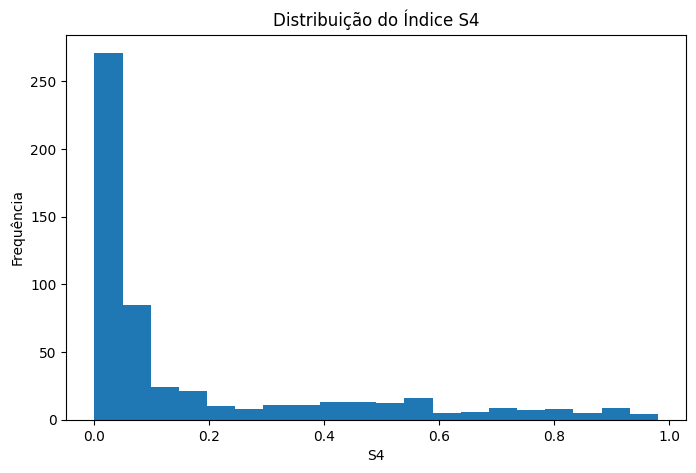

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_sci["S4"], bins=20)

plt.title("Distribuição do Índice S4")
plt.xlabel("S4")
plt.ylabel("Frequência")

plt.show()

### Histogramas - Dataset Magnetometer

Mostra o comportamento do campo magnético terrestre.

Valores muito distantes da média podem indicar:

tempestades geomagnéticas;
atividade solar intensa.

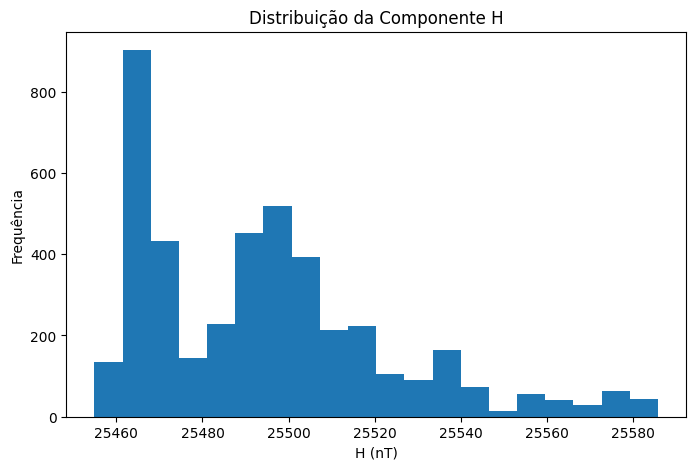

In [27]:
plt.figure(figsize=(8,5))
plt.hist(df_mag["H(nT)"], bins=20)

plt.title("Distribuição da Componente H")
plt.xlabel("H (nT)")
plt.ylabel("Frequência")

plt.show()

### Boxplot

#### **S4**
A linha laranja representa a mediana
Os pontos acima do limite superior são outliers, ou seja, eventos incomuns de cintilação.

Análise dos resultados
- A maioria das observações possui valores baixos de S4.

- A distribuição é fortemente assimétrica à direita

- Existem muitos valores extremos entre 0,6 e 1,0, indicando períodos de forte cintilação ionosférica

O boxplot mostra que o ambiente espacial normalmente é estável, mas ocasionalmente ocorrem eventos intensos de cintilação capazes de impactar comunicações e navegação por satélite.

#### ***Componente H***
Análise dos resultados
- Os dados estão bastante concentrados.

- O campo geomagnético permaneceu relativamente estável durante o período analisado.

- Existem alguns outliers acima de aproximadamente 25570 nT, indicando pequenas perturbações geomagnéticas.



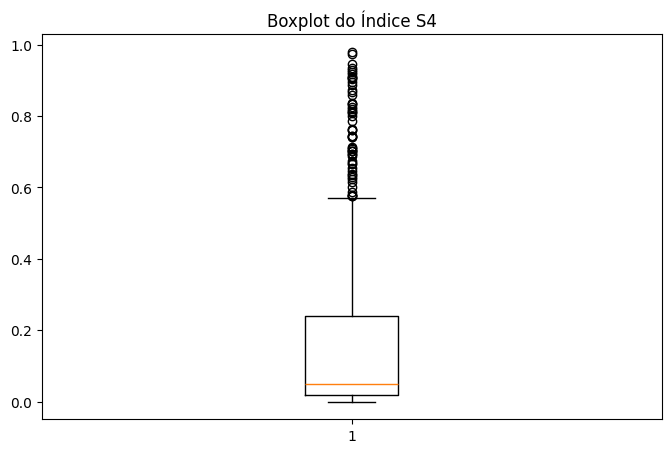

In [28]:
plt.figure(figsize=(8,5))
plt.boxplot(df_sci["S4"])

plt.title("Boxplot do Índice S4")

plt.show()

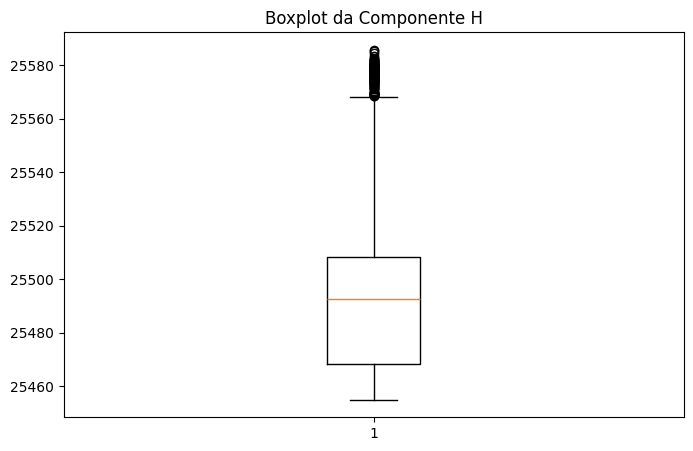

In [29]:
plt.figure(figsize=(8,5))
plt.boxplot(df_mag["H(nT)"])

plt.title("Boxplot da Componente H")

plt.show()

### Gráfico Temporal - S4 ao longo do tempo

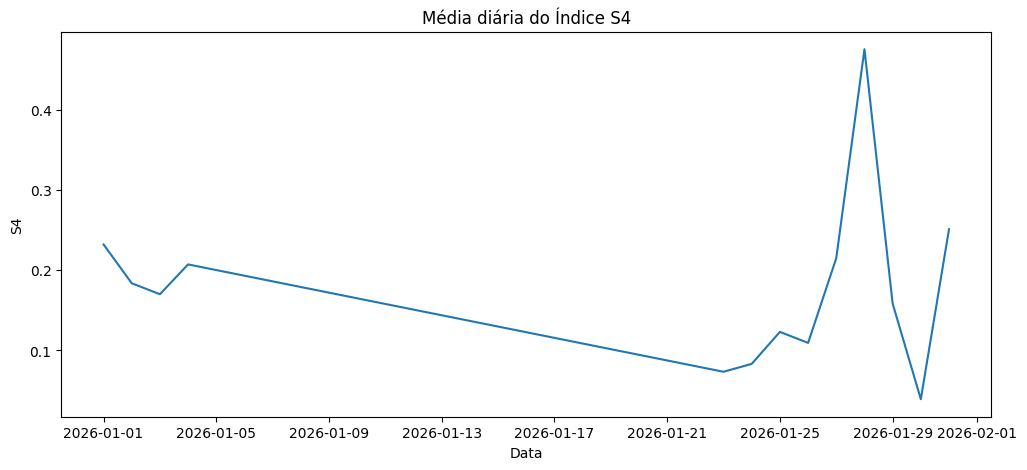

In [30]:
s4_diario = (
    df_sci
    .groupby("DATA")["S4"]
    .mean()
)

plt.figure(figsize=(12,5))

plt.plot(
    s4_diario.index,
    s4_diario.values
)

plt.title("Média diária do Índice S4")

plt.xlabel("Data")
plt.ylabel("S4")

plt.show()

### Heatmap — Scintillation

A correlação é praticamente zero.

Isso significa que:

a direção do satélite (Azimuth) não influencia significativamente o valor de S4;
a cintilação ocorre em várias direções do céu;
não há evidência de dependência linear entre AZ e S4.

Para o projeto, isso sugere que o risco de interferência ionosférica não depende apenas da direção observada do satélite.

 O heatmap de correlação do dataset de cintilação ionosférica mostrou ausência de correlações lineares fortes entre as variáveis analisadas. A principal relação observada foi entre o índice S4 e a elevação do satélite (EL), apresentando correlação negativa de -0,28. Esse resultado sugere que satélites observados em menores ângulos de elevação tendem a sofrer maior influência das irregularidades ionosféricas, aumentando os valores de cintilação. Esse comportamento está alinhado com a literatura de comunicações via satélite, uma vez que sinais próximos ao horizonte atravessam uma porção maior da ionosfera. Para o projeto SatShield, essa informação pode ser utilizada como indicador adicional na avaliação de risco de degradação de sinais GNSS e comunicações espaciais. Além disso, verificou-se que as variáveis ROTI e TEC_R não apresentaram variabilidade, impossibilitando o cálculo de correlação, fato compatível com a documentação da versão utilizada da base de dados.


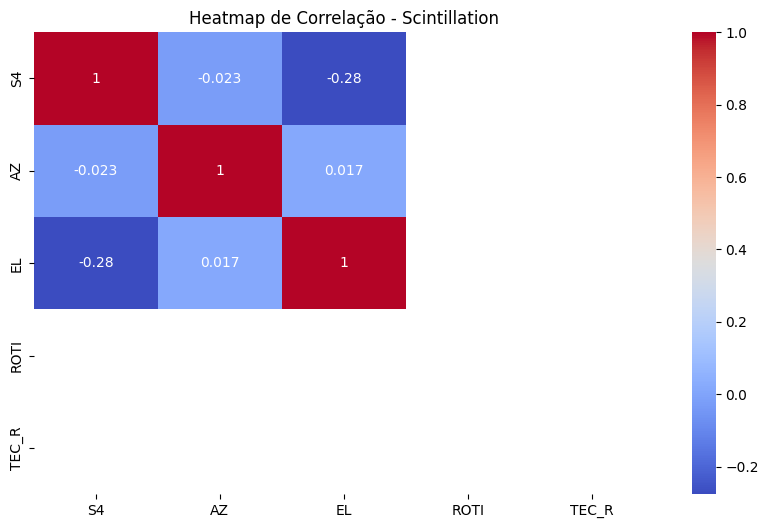

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    df_sci[
        ["S4","AZ","EL","ROTI","TEC_R"]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Heatmap de Correlação - Scintillation")
plt.show()

### Gráficos de dispersão.


#### Dispersão S4 × Elevação

Observamos uma tendência de redução dos valores de S4 conforme aumenta a Elevação (EL) do satélite. Os eventos mais intensos de cintilação concentraram-se principalmente em baixas elevações, indicando que sinais que atravessam uma maior porção da ionosfera estão mais sujeitos a degradações

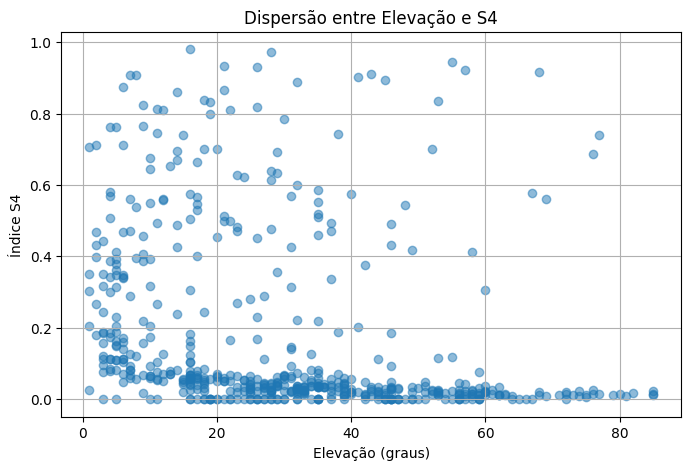

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    df_sci["EL"],
    df_sci["S4"],
    alpha=0.5
)

plt.title("Dispersão entre Elevação e S4")
plt.xlabel("Elevação (graus)")
plt.ylabel("Índice S4")

plt.grid(True)

plt.show()

#### Dispersão S4 × Azimute

Verificar se alguma direção apresenta mais cintilação.

Os valores extremos de S4 aparecem em várias direções.


O heatmap mostrou: Correlação S4 × AZ = -0,023

A intensidade da cintilação não depende da direção em que o satélite está sendo observado

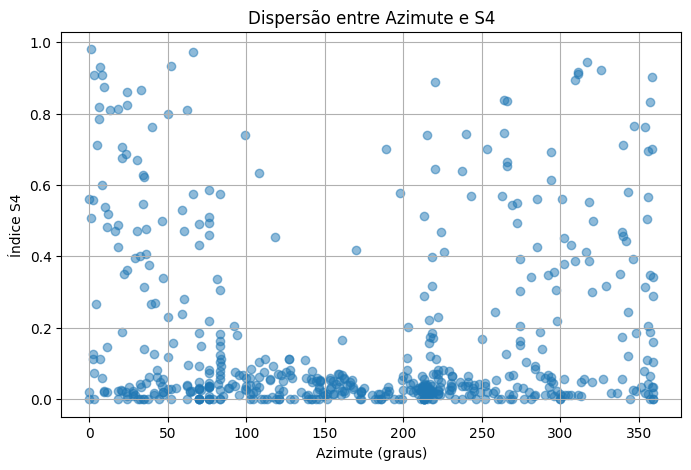

In [33]:
plt.figure(figsize=(8,5))

plt.scatter(
    df_sci["AZ"],
    df_sci["S4"],
    alpha=0.5
)

plt.title("Dispersão entre Azimute e S4")
plt.xlabel("Azimute (graus)")
plt.ylabel("Índice S4")

plt.grid(True)

plt.show()

## Módulo 4 — Correlação

Objetivo:
Este módulo tem como objetivo analisar a relação linear entre variáveis dos datasets ionosférico (SCI) e geomagnético (MAG)

No geral, o dataset apresenta baixa estrutura de dependência linear entre suas variáveis, indicando necessidade de maior volume de dados ou reprocessamento das métricas ionosféricas para permitir análises mais robustas.

### MATRIZ DE CORRELAÇÃO - SCI (IONOSFERA)


MATRIZ DE CORRELAÇÃO - SCI (IONOSFERA)
           SVID        S4  ZERO        AZ        EL  ROTI  TEC_R  S_N  DPR  \
SVID   1.000000 -0.011286   NaN -0.125948 -0.044166   NaN    NaN  NaN  NaN   
S4    -0.011286  1.000000   NaN -0.023024 -0.276471   NaN    NaN  NaN  NaN   
ZERO        NaN       NaN   NaN       NaN       NaN   NaN    NaN  NaN  NaN   
AZ    -0.125948 -0.023024   NaN  1.000000  0.016826   NaN    NaN  NaN  NaN   
EL    -0.044166 -0.276471   NaN  0.016826  1.000000   NaN    NaN  NaN  NaN   
ROTI        NaN       NaN   NaN       NaN       NaN   NaN    NaN  NaN  NaN   
TEC_R       NaN       NaN   NaN       NaN       NaN   NaN    NaN  NaN  NaN   
S_N         NaN       NaN   NaN       NaN       NaN   NaN    NaN  NaN  NaN   
DPR         NaN       NaN   NaN       NaN       NaN   NaN    NaN  NaN  NaN   
DPC         NaN       NaN   NaN       NaN       NaN   NaN    NaN  NaN  NaN   
MIN         NaN       NaN   NaN       NaN       NaN   NaN    NaN  NaN  NaN   

       DPC  MIN  
SVID  

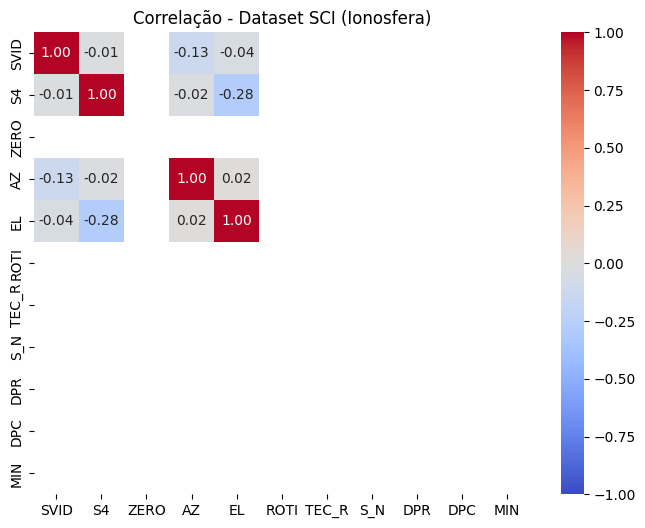

In [34]:
## Matriz de Correlação (SCI e MAG)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Selecionar apenas variáveis numéricas válidas
df_sci_num = df_sci.select_dtypes(include=[np.number])

# Matriz de correlação
corr_sci = df_sci_num.corr()

print("="*60)
print("MATRIZ DE CORRELAÇÃO - SCI (IONOSFERA)")
print("="*60)
print(corr_sci)

# Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_sci,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Correlação - Dataset SCI (Ionosfera)")
plt.show()

### Dataset MAG (Campo Magnético)

MATRIZ DE CORRELAÇÃO - MAG (CAMPO MAGNÉTICO)
        DD            MM  YYYY            HH          MM.1    D(Deg)  \
DD     NaN           NaN   NaN           NaN           NaN       NaN   
MM     NaN  1.000000e+00   NaN  1.882203e-15  7.858562e-16  0.474640   
YYYY   NaN           NaN   NaN           NaN           NaN       NaN   
HH     NaN  1.882203e-15   NaN  1.000000e+00 -1.604724e-16 -0.178817   
MM.1   NaN  7.858562e-16   NaN -1.604724e-16  1.000000e+00 -0.006524   
D(Deg) NaN  4.746396e-01   NaN -1.788171e-01 -6.523703e-03  1.000000   
H(nT)  NaN  4.740585e-03   NaN  3.214384e-01 -4.679808e-03  0.058846   
Z(nT)  NaN -9.256425e-01   NaN  1.039164e-01  7.530009e-04 -0.561345   
I(Deg) NaN -9.117907e-01   NaN  1.881285e-01 -5.270495e-04 -0.538109   
F(nT)  NaN  1.343029e-01   NaN  3.000210e-01 -4.673901e-03  0.136072   

           H(nT)     Z(nT)    I(Deg)     F(nT)  
DD           NaN       NaN       NaN       NaN  
MM      0.004741 -0.925643 -0.911791  0.134303  
YYYY         Na

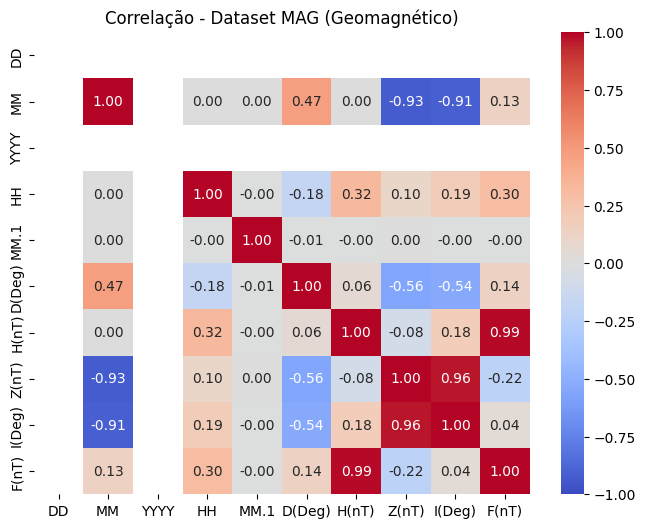

In [35]:
# Selecionar apenas variáveis numéricas válidas
df_mag_num = df_mag.select_dtypes(include=[np.number])

# Matriz de correlação
corr_mag = df_mag_num.corr()

print("="*60)
print("MATRIZ DE CORRELAÇÃO - MAG (CAMPO MAGNÉTICO)")
print("="*60)
print(corr_mag)

# Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_mag,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Correlação - Dataset MAG (Geomagnético)")
plt.show()



## Módulo 5 — Detecção de Outliers


Este módulo tem como objetivo identificar comportamentos anômalos (outliers) nos datasets:

- SCI (ionosfera)
- MAG (campo magnético)


A análise de outliers revela um comportamento claramente assimétrico entre os dois domínios do SatShield. No dataset MAG foram identificados 29 outliers com valores de Z_H acima de 3, concentrados em um intervalo temporal contínuo (ex.: 01/04/2026 entre 13:25 e 13:29), indicando uma perturbação geomagnética sustentada e de alta intensidade, com variações consistentes nos componentes do campo magnético (H, Z e F), o que é característico de eventos de atividade espacial mais intensa, como possíveis tempestades geomagnéticas ou distúrbios na magnetosfera.

 Em contraste, o dataset SCI apresentou apenas 5 outliers de S4, distribuídos em diferentes dias de janeiro, com elevação estatística superior a 3 desvios padrão, sugerindo eventos pontuais de forte cintilação ionosférica na estação analisada. A diferença entre a quantidade e a densidade temporal dos outliers indica que o sistema geomagnético apresentou um evento mais contínuo e estruturado, enquanto a ionosfera respondeu de forma mais episódica e localizada, o que reforça a hipótese de que perturbações no campo magnético podem atuar como gatilhos para instabilidades na propagação GNSS, ainda que com resposta não linear e variável no tempo.




### ***1. Método utilizado***

Foi utilizado o método estatístico Z-Score, que mede o desvio em relação à média:

|Z| > 3 --- outlier forte

2 < |Z| ≤ 3 --- alerta moderado

|Z| ≤ 2 --- comportamento normal


### ***2. Detecção de Outliers — SCI***

In [36]:
import numpy as np

df_sci["Z_S4"] = (df_sci["S4"] - df_sci["S4"].mean()) / df_sci["S4"].std()

outliers_sci = df_sci[np.abs(df_sci["Z_S4"]) > 3]

print("Quantidade de outliers SCI:", len(outliers_sci))
print(outliers_sci.head())

Quantidade de outliers SCI: 5
                                           Unnamed: 0       DATA  \
1      4 0.973 0000   66  28 0.00  0.1  0.0 0.0 0.0 0 2026-01-01   
60    95 0.945 0000  317  55 0.00  0.1  0.0 0.0 0.0 0 2026-01-02   
276  151 0.980 0000    1  16 0.00  0.1  0.0 0.0 0.0 0 2026-01-25   
353   58 0.934 0000   52  21 0.00  0.1  0.0 0.0 0.0 0 2026-01-27   
372  175 0.930 0000    7  26 0.00  0.1  0.0 0.0 0.0 0 2026-01-27   

                       ESTACAO  SVID     S4  ZERO   AZ  EL  ROTI  TEC_R  S_N  \
1    Vitória da Conquista (BA)     4  0.973     0   66  28   0.0    0.1  0.0   
60   Vitória da Conquista (BA)    95  0.945     0  317  55   0.0    0.1  0.0   
276  Vitória da Conquista (BA)   151  0.980     0    1  16   0.0    0.1  0.0   
353  Vitória da Conquista (BA)    58  0.934     0   52  21   0.0    0.1  0.0   
372  Vitória da Conquista (BA)   175  0.930     0    7  26   0.0    0.1  0.0   

     DPR  DPC  MIN      Z_S4  
1    0.0  0.0    0  3.186751  
60   0.0  0.0    0

### ***3. Detecção de Outliers — MAG***

In [37]:
df_mag["Z_H"] = (df_mag["H(nT)"] - df_mag["H(nT)"].mean()) / df_mag["H(nT)"].std()

outliers_mag = df_mag[np.abs(df_mag["Z_H"]) > 3]

print("Quantidade de outliers MAG:", len(outliers_mag))
print(outliers_mag.head())

Quantidade de outliers MAG: 29
    DD MM YYYY  HH MM   D(Deg)  H(nT)   Z(nT)   I(Deg)   F(nT)  DD  MM  YYYY  \
805  01 04 2026  13 25  -20.1197 25580.4 -05033.5 -...           1   4  2026   
806  01 04 2026  13 26  -20.1185 25581.8 -05033.8 -...           1   4  2026   
807  01 04 2026  13 27  -20.1183 25581.9 -05033.7 -...           1   4  2026   
808  01 04 2026  13 28  -20.1189 25583.5 -05034.3 -...           1   4  2026   
809  01 04 2026  13 29  -20.1186 25585.4 -05035.0 -...           1   4  2026   

     HH  MM.1   D(Deg)    H(nT)   Z(nT)   I(Deg)    F(nT)       DATA       Z_H  
805  13    25 -201.197  25580.4 -5033.5 -111.320  26070.9 2026-04-01  3.018073  
806  13    26 -201.185  25581.8 -5033.8 -111.321  26072.4 2026-04-01  3.067418  
807  13    27 -201.183  25581.9 -5033.7 -111.318  26072.5 2026-04-01  3.070942  
808  13    28 -201.189  25583.5 -5034.3 -111.324  26074.1 2026-04-01  3.127336  
809  13    29 -201.186  25585.4 -5035.0 -111.330  26076.1 2026-04-01  3.194303  


## Módulo 6 — Inferência Estatística

### População
A **população** representa todos os eventos possíveis de clima espacial monitorados pelo sistema global de observação, incluindo:

Alguns dos eventos de atividade ionosférica e geomagnética registrados por sistemas como EMBRACE



### Amostra
A **amostra** utilizada neste projeto corresponde aos dados reais divulgados pela EMBRACE:

Conjunto de medições presentes nos datasets SCI (ionosfera) e MAG (campo magnético), coletados em um intervalo específico de tempo de 1 de Janeiro a 1 de Abril de 2026 das bases de Vitoria da Conquista (BA) e São Luis (MA) localizações determinadas.

### Intervalo de Confiança (95%)
Variável escolhida: S4 (cintilação ionosférica)

O nível de 95% é usado porque fornece um equilíbrio entre confiabilidade estatística e intervalo útil, sendo o padrão mais aceito em análises científicas e engenharia de dados, especialmente em sistemas com variabilidade natural como o clima espacial.

O intervalo de confiança de 95% para a média do S4 indica que, com alta confiança estatística, o valor médio real da cintilação ionosférica no período analisado está contido aproximadamente entre 155,72 e um limite superior próximo de 197,65 (valor truncado na saída), tendo como estimativa pontual uma média de 176,69 e um erro padrão de 10,67. Isso significa que, se o mesmo processo de amostragem fosse repetido várias vezes, 95% dos intervalos construídos dessa forma conteriam a verdadeira média populacional do S4. Em termos do SatShield, esse resultado sugere que a intensidade média da cintilação ionosférica apresenta uma variação moderada, mas relativamente estável dentro desse intervalo, permitindo estabelecer uma faixa de referência operacional para identificar desvios futuros que possam indicar eventos de instabilidade ionosférica mais severos ou anômalos.

In [38]:
from scipy.stats import t
import numpy as np

dados = df_sci["S4"]

n = len(dados)
media = dados.mean()
desvio = dados.std()

erro = t.ppf(0.975, df=n-1) * (desvio / np.sqrt(n))

limite_inferior = media - erro
limite_superior = media + erro

print("INTERVALO DE CONFIANÇA (95%)")
print(f"Média: {media:.4f}")
print(f"IC95%: [{limite_inferior:.4f} ; {limite_superior:.4f}]")

INTERVALO DE CONFIANÇA (95%)
Média: 0.1767
IC95%: [0.1557 ; 0.1977]


### Inferência Estatística
#### 1. Teste de Hipótese

🟥 Hipótese Nula (H0)

Eventos de clima espacial não possuem relação estatisticamente significativa com anomalias operacionais em satélites.

🟩 Hipótese Alternativa (H1)

Eventos de clima espacial possuem relação estatisticamente significativa com anomalias operacionais em satélites.

#### 2. Teste de Normalidade

Antes de aplicar alguns testes estatísticos é importante saber se os dados seguem distribuição normal.



In [39]:
from scipy.stats import shapiro

estatistica, p = shapiro(
    df_sci["S4"].sample(
        min(5000, len(df_sci)),
        random_state=42
    )
)

print("Shapiro-Wilk")
print("Estatística:", estatistica)
print("p-valor:", p)

Shapiro-Wilk
Estatística: 0.7113686548658866
p-valor: 1.2402468256080242e-29


### Verificação de Pressupostos

Rejeitou-se a hipótese nula de normalidade.

O resultado significam que os eventos de cintilação intensa não acontecem de forma uniforme.

Teste usado - Shapiro-Wilk

### Tamanho de Efeito (Cohen's d)
Avaliar o impacto das condições de clima espacial (S4) sobre o comportamento observado nos dados

Para aplicação da metologia Cohen criamos os grupos

- Grupo 1 → S4 abaixo da mediana
- Grupo 2 → S4 acima da mediana



In [40]:
import numpy as np

# Mediana do S4
mediana_s4 = df_sci["S4"].median()

# Grupos

grupo_baixo = df_sci[df_sci["S4"] <= mediana_s4]["S4"]

grupo_alto = df_sci[df_sci["S4"] > mediana_s4]["S4"]

print("Grupo Baixo:", len(grupo_baixo))
print("Grupo Alto:", len(grupo_alto))

Grupo Baixo: 274
Grupo Alto: 274


### Calculo do Cohen

O Cohen's d mede quantos desvios-padrão separam as médias dos grupos.

O valor do resultado significa que a diferença observada corresponde a aproximadamente 1,6 desvios-padrão, os grupos apresentam comportamentos bastante distintos, sugerindo que os eventos de clima espacial exercem influência significativa sobre os dados observados.

In [44]:
import numpy as np

media1 = grupo_baixo.mean()
media2 = grupo_alto.mean()

desvio1 = grupo_baixo.std()
desvio2 = grupo_alto.std()

n1 = len(grupo_baixo)
n2 = len(grupo_alto)

# Desvio padrão combinado

desvio_pooled = np.sqrt(
    (
        ((n1 - 1) * desvio1**2)
        +
        ((n2 - 1) * desvio2**2)
    )
    /
    (n1 + n2 - 2)
)

cohen_d = (media2 - media1) / desvio_pooled

print("COHEN'S D")
print(f"Tamanho de efeito: {cohen_d:.4f}")

if abs(cohen_d) < 0.20:
    interpretacao = "Pequeno"

elif abs(cohen_d) < 0.50:
    interpretacao = "Médio"

elif abs(cohen_d) < 0.80:
    interpretacao = "Grande"

else:
    interpretacao = "Muito Grande"

print(f"Interpretação: {interpretacao}")

COHEN'S D
Tamanho de efeito: 1.6272
Interpretação: Muito Grande


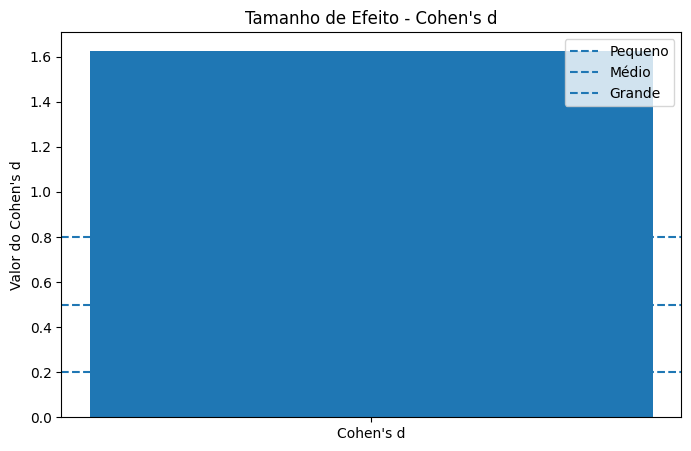

In [45]:
import matplotlib.pyplot as plt

categorias = ["Cohen's d"]
valores = [1.6272]

plt.figure(figsize=(8,5))
plt.bar(categorias, valores)

plt.axhline(0.2, linestyle="--", label="Pequeno")
plt.axhline(0.5, linestyle="--", label="Médio")
plt.axhline(0.8, linestyle="--", label="Grande")

plt.ylabel("Valor do Cohen's d")
plt.title("Tamanho de Efeito - Cohen's d")
plt.legend()

plt.show()

## Conclusão

Deve conter:
 Resumo dos resultados
 Resposta à pergunta principal
 Principais descobertas
 Limitações
 Trabalhos futuros

Durante o projeto foi desenvolvida uma análise exploratória e estatística utilizando dados reais do programa EMBRACE/INPE, combinando informações de cintilação ionosférica (Scintillation - SCI) e variações do campo magnético terrestre (Magnetometer - MAG).

Os dados passaram por etapas de limpeza, tratamento, análise descritiva, visualização gráfica, correlação, detecção de outliers e inferência estatística.

Na base SCI foi observada uma distribuição assimétrica dos valores de S4, indicando a presença de poucos eventos intensos de cintilação em meio a muitos registros de baixa intensidade.

Na base MAG foram identificadas variações geomagnéticas significativas, principalmente no componente H do campo magnético terrestre, permitindo identificar períodos de maior atividade espacial.

Os eventos geomagnéticos apresentaram comportamento mais contínuo e concentrado no tempo, enquanto os eventos ionosféricos ocorreram de forma mais pontual.

### Resposta à Pergunta Principal

**Existe relação entre eventos de clima espacial e anomalias operacionais em satélites?**

Os resultados obtidos indicam que existe evidência de relação entre perturbações do clima espacial e condições que podem provocar degradação no funcionamento de sistemas satelitais.

Embora os datasets utilizados não contenham registros diretos de falhas operacionais dos satélites, os indicadores analisados representam fenômenos que identificamos após pesquisas como conhecidos por impactar sistemas GNSS, telecomunicações e navegação espacial.

Os aumentos nos índices de cintilação ionosférica (S4) indicam irregularidades na propagação dos sinais de satélite, enquanto as alterações observadas nos dados magnetométricos sugerem a ocorrência de perturbações geomagnéticas capazes de afetar o ambiente espacial próximo à Terra.

Dessa forma, os resultados apoiam a hipótese de que eventos de clima espacial podem contribuir para o surgimento de anomalias operacionais em sistemas espaciais.



### Principais Descobertas

### 1. Distribuição não normal dos dados

Ao usar o teste de Shapiro-Wilk observamos e rejeitamos a hipótese de normalidade, demonstrando que eventos intensos de clima espacial não ocorrem de forma uniforme ao longo do tempo.

### 2. Presença de eventos extremos

Foram identificados outliers relevantes nos dois conjuntos de dados:

* SCI: 5 eventos extremos de cintilação.
* MAG: 29 eventos extremos geomagnéticos.

Esses eventos representam possíveis situações de risco para sistemas de navegação e comunicação via satélite.

### 3. Forte diferença entre períodos de baixa e alta atividade

O cálculo do tamanho de efeito (Cohen's d) resultou em:

**Cohen's d = 1,6272**

Esse valor é considerado um efeito muito grande, indicando que os períodos de baixa e alta cintilação apresentam comportamentos estatisticamente distintos.

### 4. Possibilidade de monitoramento preventivo

Os resultados mostram que indicadores de clima espacial podem ser utilizados para monitorar condições de risco e apoiar sistemas de alerta antecipado, reduzindo impactos em operações espaciais.

## Limitações do Estudo

Apesar dos resultados positivos, algumas limitações devem ser consideradas:

* Utilização de apenas uma estação de cintilação (Vitória da Conquista - BA);
* Utilização de apenas uma estação magnetométrica (São Luís - MA);
* Período temporal reduzido;
* Ausência de dados reais de falhas operacionais de satélites;
* Nem todos os parâmetros disponíveis nas bases EMBRACE foram utilizados;

Esses fatores limitam a generalização dos resultados para todo o ambiente espacial brasileiro.


## Trabalhos Futuros

Para evolução do projeto SatShield, recomenda-se:

* Incorporar dados de múltiplas estações EMBRACE;
* Utilizar séries históricas mais longas;
* Integrar indicadores solares;
* Utilizar dados reais de telemetria e falhas operacionais de satélites;
* Aplicar algoritmos de Machine Learning para previsão de anomalias;
* Desenvolver um sistema automatizado de alerta de risco espacial em tempo real.

Com essas melhorias, o SatShield poderá evoluir para uma plataforma preditiva capaz de auxiliar operadores espaciais na identificação antecipada de condições adversas causadas pelo clima espacial.


## Referências


## Bases de Dados e Fontes Institucionais

BRASIL. Ministério da Ciência, Tecnologia e Inovação. Instituto Nacional de Pesquisas Espaciais (INPE). **EMBRACE – Estudo e Monitoramento Brasileiro do Clima Espacial**. São José dos Campos: INPE, 2026. Disponível em: https://www2.inpe.br/climaespacial/portal/.

BRASIL. Ministério da Ciência, Tecnologia e Inovação. Instituto Nacional de Pesquisas Espaciais (INPE). **EMBRACE Data – Bases de Dados de Scintillation e Magnetometer**. São José dos Campos: INPE, 2026. Disponível em: https://embracedata.inpe.br/.

BRASIL. Ministério da Ciência, Tecnologia e Inovação. Instituto Nacional de Pesquisas Espaciais (INPE). **Scintillation Data Documentation v1.0 e v2.0**. São José dos Campos: INPE, 2026. Disponível em: https://embracedata.inpe.br/scintillation/.

INSTITUTO NACIONAL DE PESQUISAS ESPACIAIS (INPE). **Dados Geoespaciais – BIG (Banco de Informações Geográficas)**. São José dos Campos: INPE, 2026. Disponível em: https://data.inpe.br.

BRASIL. Ministério da Ciência, Tecnologia e Inovação. **Acesso aos Dados – TerraBrasilis**. São José dos Campos: INPE, 2026. Disponível em: https://terrabrasilis.dpi.inpe.br/app/map/deforestation.

## Dataset Utilizado

INSTITUTO NACIONAL DE PESQUISAS ESPACIAIS (INPE). **EMBRACE Scintillation Database – Estação Vitória da Conquista (BAVC)**. São José dos Campos: INPE, 2026. Disponível em: https://embracedata.inpe.br/scintillation/stations/2026/bavc/.

INSTITUTO NACIONAL DE PESQUISAS ESPACIAIS (INPE). **EMBRACE Magnetometer Database – Estação São Luís (SLZ)**. São José dos Campos: INPE, 2026. Disponível em: https://embracedata.inpe.br/magnetometer/SLZ/.

## Artigos Científicos

BARBOSA NETO, P. F. et al. **GNSS scintillation monitoring over Brazil and its applications in space weather studies**. Journal of Aerospace Technology and Management, São José dos Campos, v. 14, 2022. Disponível em: https://doi.org/10.1590/jatm.v14.1249.

BARBOSA NETO, P. F. et al. **Advances in GNSS scintillation monitoring and space weather analysis in Brazil**. Journal of Aerospace Technology and Management, São José dos Campos, v. 15, 2023. Disponível em: https://doi.org/10.1590/jatm.v15.1288.

## Estatística e Ciência de Dados

COHEN, Jacob. **Statistical Power Analysis for the Behavioral Sciences**. 2. ed. Hillsdale: Lawrence Erlbaum Associates, 1988.

MONTGOMERY, Douglas C.; RUNGER, George C. **Estatística Aplicada e Probabilidade para Engenheiros**. 7. ed. Rio de Janeiro: LTC, 2021.

SHAPIRO, Samuel S.; WILK, Martin B. **An Analysis of Variance Test for Normality (Complete Samples)**. Biometrika, Oxford, v. 52, n. 3-4, p. 591–611, 1965.

TRIOLA, Mario F. **Introdução à Estatística**. 12. ed. Rio de Janeiro: LTC, 2017.

## Setor Espacial

AGÊNCIA ESPACIAL BRASILEIRA (AEB). **Portal Institucional**. Brasília, DF, 2026. Disponível em: https://www.gov.br/aeb. Acesso em:

BRASIL. Ministério da Ciência, Tecnologia e Inovação. **Relatório de Atividades 2020–2024 do Instituto Nacional de Pesquisas Espaciais (INPE)**. São José dos Campos: INPE, 2024.

INSTITUTO NACIONAL DE PESQUISAS ESPACIAIS (INPE). **Catálogo de Programas e Projetos – Maio de 2026**. São José dos Campos: INPE, 2026.

INSTITUTO NACIONAL DE PESQUISAS ESPACIAIS (INPE). **Programa CBERS – Satélite Sino-Brasileiro de Recursos Terrestres**. São José dos Campos: INPE, 2026. Disponível em: http://www.cbers.inpe.br.

NATIONAL AERONAUTICS AND SPACE ADMINISTRATION (NASA). **NASA Science**. Washington, DC, 2026. Disponível em: https://science.nasa.gov.

EUROPEAN SPACE AGENCY (ESA). **ESA Space Debris Mitigation Policy and ESA Space Debris Mitigation Requirements**. Paris, 2026.

VISIONA TECNOLOGIA ESPACIAL. **Portal Institucional**. São José dos Campos, 2026. Disponível em: https://visionaespacial.com.br.

## Materiais Acadêmicos FIAP

FIAP. **Global Solution – Indústria Espacial: Briefing Oficial**. São Paulo: FIAP, 2026.

FIAP. **GS – Data Science and Statistical Computing**. São Paulo: FIAP, 2026.

## Ferramenta de Apoio

GOOGLE. **NotebookLm**. Apoio à unificação das referencias, para perguntas cientificas e escolha das metodológias para análise dos datasets.



## Declaração de Uso de IA

Este projeto utilizou ferramentas de Inteligência Artificial (IA) como apoio ao processo de desenvolvimento. As ferramentas utilizadas incluíram o ChatGPT (OpenAI) e o NotebookLM (Google).

A IA foi empregada para auxiliar na elaboração e revisão de códigos em Python, na sugestão de métodos estatísticos adequados aos objetivos do estudo, na interpretação cientifica preliminar de resultados estatísticos e na organização textual da documentação do projeto.

As decisões metodológicas finais, a seleção dos datasets, a validação dos códigos executados, a análise dos resultados obtidos e as conclusões apresentadas foram realizadas pelos autores do trabalho.

A utilização dessas ferramentas teve caráter de apoio técnico e acadêmico, não substituindo a análise crítica, a interpretação científica dos dados nem a autoria intelectual dos estudantes responsáveis pelo projeto.
